# Exercise 4 — Dimensionality Reduction

## Part A — Why Do We Need Dimensionality Reduction?

Real datasets often contain many features.

Example:
```
apartment:
- size
- number of rooms
- floor
- location score
- age
- distance to center
- noise level
- energy consumption
...
```

As the number of features increases:

* visualization becomes difficult
* models become slower
* features may become redundant
* noise increases
* overfitting becomes easier

This is related to: `the curse of dimensionality`

### Goal of Dimensionality Reduction

Reduce the number of features while preserving the important structure of the data.

### Main Idea

Instead of describing the data with many correlated features: `(size, rooms, floor, age, ...)` we create: `new compact features` called `principal components`.

If two features contain similar information: `size ↔ number of rooms` then we may not need both.

PCA tries to find:

* the main directions of variation
* the most informative axes

## Part B — Generate Correlated Data

In [50]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Apartment example
n = 300

size = np.random.normal(70, 15, n)

rooms = size / 25 + np.random.normal(0, 0.35, n)

X = np.column_stack([size, rooms])

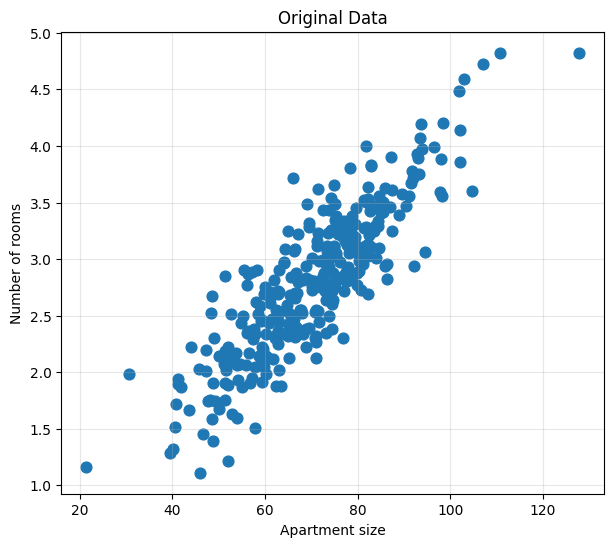

In [51]:
plt.figure(figsize=(7,6))

plt.scatter(X[:,0], X[:,1], s=60)

plt.xlabel("Apartment size")
plt.ylabel("Number of rooms")

plt.title("Original Data")

plt.grid(True, alpha=0.3)

plt.show()

### Questions

1. Are the features correlated? Yes because both are predicting (either directly or indirectly) the ideal apartment to live. 
2. Does the cloud follow a direction? Yes, upward from lower number of rooms at [x, y] = [40, 1.5] to upper [x, y] = [100, 4.0]
3. Could one feature approximately predict the other? probably. like for in this example, bigger apartment size does translate to better number of rooms.

## Part C — Apply PCA

Standardize the data. Why do we need to do this?

Data standardization is the process of scaling variables so they have a mean of 0 and a standard deviation 1. It is a mandatory first step in PCA to prevent features with larger units or magnitudes from disproportionately dominating the analysis.

In [52]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Run PCA

In [53]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

### Explained Variance

In [54]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.9319629 0.0680371]


`PC1 = direction with maximum variance`

PCA tries to find the direction where the data spreads the most.

### Visualize PCA Directions

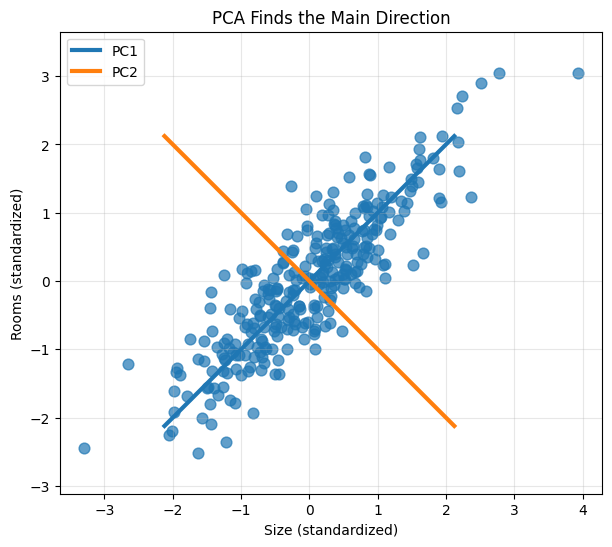

In [55]:
mean = X_scaled.mean(axis=0)

pc1 = pca.components_[0]
pc2 = pca.components_[1]

t = np.linspace(-3, 3, 100)

pc1_line = mean + t[:, None] * pc1
pc2_line = mean + t[:, None] * pc2

plt.figure(figsize=(7,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    s=60,
    alpha=0.7
)

plt.plot(
    pc1_line[:,0],
    pc1_line[:,1],
    linewidth=3,
    label="PC1"
)

plt.plot(
    pc2_line[:,0],
    pc2_line[:,1],
    linewidth=3,
    label="PC2"
)

plt.xlabel("Size (standardized)")
plt.ylabel("Rooms (standardized)")

plt.title("PCA Finds the Main Direction")

plt.legend()

plt.grid(True, alpha=0.3)

plt.axis("equal")

plt.show()

### Questions

1. Why does PCA choose this direction? The PCA would choose this direction because pca asks for the strongest directions where data varies the most.
2. What does “maximum variance” mean visually? "Variance" in ML means the spread of the data distribution of the learning model. So the maximum variance just explain the maximum spread of the variance. 
3. Why is this direction informative? It is like linear regression, finds the data, finds the ideal variance.

## Part D — Reduce to One Dimension

In [56]:
pca_1d = PCA(n_components=1)

X_reduced = pca_1d.fit_transform(X_scaled)

print(X_reduced.shape)

(300, 1)


### Before vs After PCA

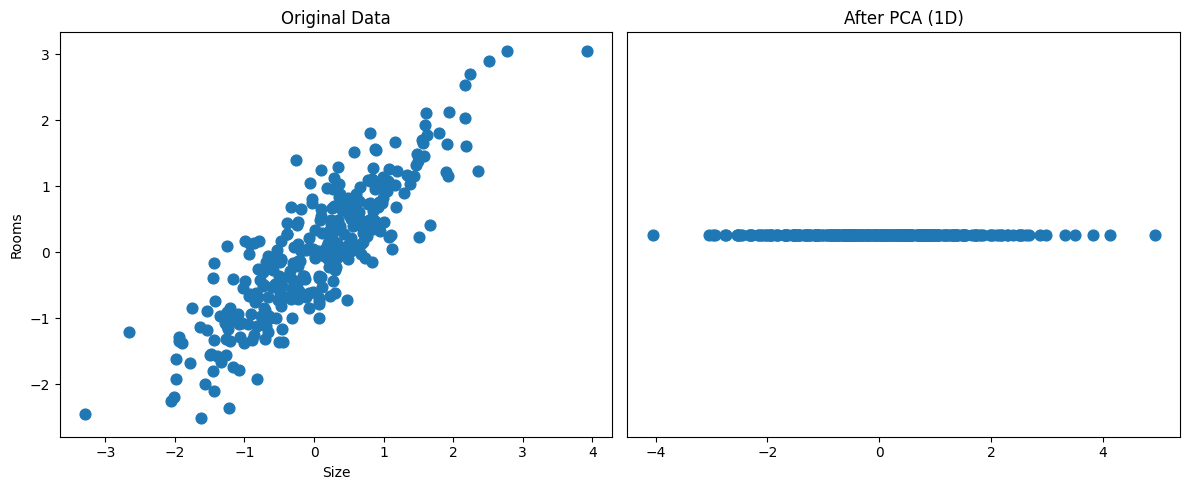

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Original
axes[0].scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    s=60
)

axes[0].set_title("Original Data")
axes[0].set_xlabel("Size")
axes[0].set_ylabel("Rooms")

# Reduced
axes[1].scatter(
    X_reduced[:,0],
    np.zeros_like(X_reduced[:,0]),
    s=60
)

axes[1].set_title("After PCA (1D)")
axes[1].set_yticks([])

plt.tight_layout()

plt.show()

Even after reducing dimensions: `similar apartments stay close together`

PCA compresses the data while preserving important relationships.

## Part E — Real Dataset

Now apply PCA to a real dataset.

Choose one dataset from the table below.

| Dataset | Link | Features | What PCA can help with |
|---|---|---|---|
| Iris | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html) | flower measurements | visualize species in 2D |
| Wine | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) | chemical properties | reduce many chemical features |
| Breast Cancer Wisconsin | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) | tumor measurements | visualize benign vs malignant cases |
| Digits | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html) | image pixels | compress image features |
| Palmer Penguins | [Open dataset](https://github.com/allisonhorst/palmerpenguins) | biological measurements | visualize species groups |
| Wine Quality | [Open dataset](https://archive.ics.uci.edu/dataset/186/wine+quality) | chemical properties | reduce correlated wine features |

In [58]:
from sklearn.datasets import load_wine

wine = load_wine()

X = wine.data
y = wine.target

### Apply PCA to 2D

In [59]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

### Visualize Reduced Data

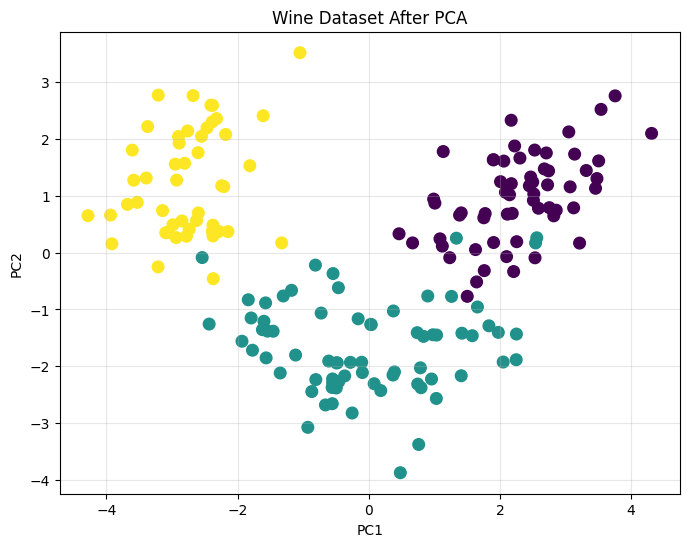

In [60]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    s=70
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Wine Dataset After PCA")

plt.grid(True, alpha=0.3)

plt.show()

### Questions

1. Do the classes separate well? for the most part it is quite well, there are some minor overlappings with other clusters.
2. Which species overlap? inside there are three species. species 1 has none, species 2 and 3 have some very minor overlapping.
3. Why is PCA useful for visualization? because the datas can be correlated. so the PCA will try to make them not correlated to eachother -> better seperation, clearer clusters.
4. Why can PCA help machine learning models? still the same premis : less dimensions -> usually much faster model, less RAM consumptions to train.

## Part F — Train a Model with Logistic Regression and PCA


Look in the previous exercises and find how to load a dataset, separate it in train/dev/test or just train/dev datasets. 

1. Use [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) or [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) depending on the task to train and test a model. Please report accuracy, precision and recall.
2. Use then PCA to reduce the dimensionality of the data, and redo step 1. Report metrics and see the difference. Is there any?

In [ ]:
#See the explained variance -> 


In [3]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score

# load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# Separate into train and test datasets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize the features (mandatory before PCA and recommended for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train and evaluate without PCA (all 4 features)
clf_original = LogisticRegression(random_state=42)
clf_original.fit(X_train_scaled, y_train)
y_pred_original = clf_original.predict(X_test_scaled)

acc_orig = accuracy_score(y_test, y_pred_original)
prec_orig = precision_score(y_test, y_pred_original, average='macro')
rec_orig = recall_score(y_test, y_pred_original, average='macro')

print("=== 1. Performance WITHOUT PCA===")
print(f"Accuracy:  {acc_orig:.4f}")
print(f"Precision: {prec_orig:.4f}")
print(f"Recall:    {rec_orig:.4f}\n")


# train and evaluate WITH PCA (reduced to 2 components) 
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

clf_pca = LogisticRegression(random_state=42)
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_pca)
prec_pca = precision_score(y_test, y_pred_pca, average='macro')
rec_pca = recall_score(y_test, y_pred_pca, average='macro')

print("=== 2. Performance WITH PCA ===")
print(f"Accuracy:  {acc_pca:.4f}")
print(f"Precision: {prec_pca:.4f}")
print(f"Recall:    {rec_pca:.4f}")

=== 1. Performance WITHOUT PCA===
Accuracy:  0.9333
Precision: 0.9333
Recall:    0.9333

=== 2. Performance WITH PCA ===
Accuracy:  0.9000
Precision: 0.9024
Recall:    0.9000
